In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("spotify_millsongdata.csv")

In [6]:
df["cleaned_text"]=(
    df["text"]
    .str.lower()
    .str.replace(r"\r\n", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [7]:
love_lexicon = {
    "direct_love": [],
    "affection": [],
    "longing":[],
    "courtship":[],
    "commitment":[],
    "endearment":[],
    "poetic":[],
    "archaic": []
}

In [8]:
love_lexicon["direct_love"] = [
    "love",
    "loved",
    "loving",
    "loves",
    "lover",
    "beloved",
    "loveless",
    "lovable"
]

In [9]:
love_lexicon["affection"] = [
    "adore",
    "adored",
    "adoring",
    "cherish",
    "cherished",
    "affection",
    "fondness",
    "devotion",
    "devoted"
]

In [10]:
love_lexicon["longing"] = [
    "yearn",
    "yearning",
    "long",
    "longing",
    "desire",
    "desired",
    "crave",
    "craving",
    "pine",
    "pining"
]

In [11]:
love_lexicon["archaic"] = [
    "thee",
    "thou",
    "thy",
    "thine",
    "loveth",
    "lovest",
    "lov'd",
    "belov'd"
]

In [12]:
for category, words in love_lexicon.items():
    print(f"{category}: {len(words)} words")

direct_love: 8 words
affection: 9 words
longing: 10 words
courtship: 0 words
commitment: 0 words
endearment: 0 words
poetic: 0 words
archaic: 8 words


In [13]:
love_lexicon["endearment"] = [
    "darling",
    "dearest",
    "sweetheart",
    "sweetie",
    "honey",
    "baby",
    "babe",
    "angel",
    "precious",
    "beloved",
    "dear",
    "cutie",
    "sunshine",
    "beautiful",
    "handsome"
]

In [14]:
love_lexicon["courtship"] = [
    "court",
    "woo",
    "betroth",
    "engage",
    "engaged",
    "marry",
    "married",
    "wedding",
    "proposal",
    "propose",
    "romance",
    "romantic",
    "dating",
    "flirt",
    "flirting"
]

In [15]:
love_lexicon["commitment"] = [
    "forever",
    "always",
    "eternal",
    "faithful",
    "loyal",
    "promise",
    "promised",
    "vow",
    "vows",
    "marriage",
    "devotion",
    "together",
    "lifelong",
    "soulmate",
    "destiny"
]

In [16]:
love_lexicon["poetic"] = [
    "ardor",
    "rapture",
    "enchant",
    "enchanted",
    "passion",
    "passionate",
    "bliss",
    "desire",
    "ecstasy",
    "yearning",
    "embrace",
    "caress",
    "tender",
    "tenderness",
    "affinity"
]

In [17]:
for category, words in love_lexicon.items():
    print(f"{category}: {len(words)} words")

direct_love: 8 words
affection: 9 words
longing: 10 words
courtship: 15 words
commitment: 15 words
endearment: 15 words
poetic: 15 words
archaic: 8 words


In [18]:
from collections import Counter

In [19]:
all_love_words = []
for words in love_lexicon.values():
    all_love_words.extend(words)
all_love_words = set(all_love_words)
print(f"Total unique love words: {len(all_love_words)}")

Total unique love words: 91


In [20]:
sample_song = df["cleaned_text"].iloc[0]
words = sample_song.split()
matches =[word for word in words if word in all_love_words]
Counter(matches)

Counter()

In [21]:
Counter({'love':3,
         'darling':1,
         'beloved':1})

Counter({'love': 3, 'darling': 1, 'beloved': 1})

In [22]:
print("Love words found:", len(matches))
print(matches)

Love words found: 0
[]


In [23]:
df[df["cleaned_text"].str.contains("love", case =False)][["artist", "song"]].head(10)

,artist,song
2,ABBA,As Good As New
3,ABBA,Bang
4,ABBA,Bang-A-Boomerang
7,ABBA,Chiquitita
10,ABBA,Dance
12,ABBA,Disillusion
14,ABBA,Dream World
16,ABBA,Eagle
21,ABBA,From A Twinkling Star To A Passing Angel
24,ABBA,Gonna Sing You My Lovesong


In [24]:
sample_song = df["cleaned_text"].iloc[215]

In [25]:
words = sample_song.split()
matches = [word for word in words if word in all_love_words]
Counter(matches)

Counter({'love': 9, 'desire': 1, 'bliss': 1})

In [26]:
from collections import Counter
def analyze_song(song_text):
    words = song_text.split()
    matches= [word for word in words if word in all_love_words]
    print("Total love words:", len(matches))
    print("\nWord Frequencies:")
    print(Counter(matches))
    return Counter(matches)

In [27]:
analyze_song(df["cleaned_text"].iloc[215])

Total love words: 11

Word Frequencies:
Counter({'love': 9, 'desire': 1, 'bliss': 1})


Counter({'love': 9, 'desire': 1, 'bliss': 1})

In [28]:
def analyze_song_by_category(song_text):
    words = song_text.split()
    category_counts ={}
    for category, lexicon_words in love_lexicon.items():
        count = sum(word in lexicon_words for word in words)
        category_counts[category] = count
    return category_counts


In [29]:
result = analyze_song_by_category(df["cleaned_text"].iloc[215])

In [30]:
print(result)

{'direct_love': 9, 'affection': 0, 'longing': 1, 'courtship': 0, 'commitment': 0, 'endearment': 0, 'poetic': 2, 'archaic': 0}


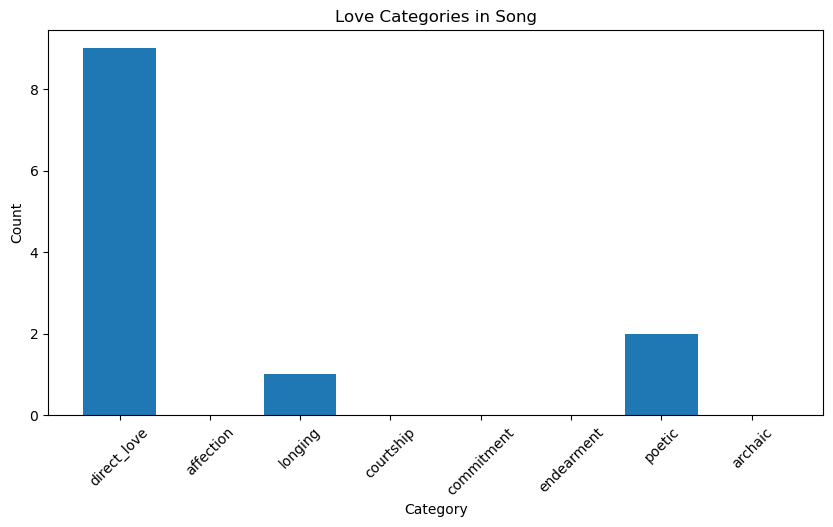

In [31]:
import matplotlib.pyplot as plt
categories = list(result.keys())
counts = list(result.values())
plt.figure(figsize=(10,5))
plt.bar(categories,counts)
plt.title("Love Categories in Song")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [32]:
def analyze_song_by_category(song_text):
    words = song_text.split()
    category_counts ={}
    for category, lexicon_words in love_lexicon.items():
        category_counts[category] = sum(word in lexicon_words for word in words)
    return category_counts
results = df["cleaned_text"].apply(analyze_song_by_category)
results_df = pd.DataFrame(results.tolist())
df = pd.concat([df, results_df], axis=1)
df.head()

,artist,song,link,text,cleaned_text,direct_love,affection,longing,courtship,commitment,endearment,poetic,archaic
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA...","look at her face, it's a wonderful face and it...",0,0,0,0,0,0,0,0
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen...","take it easy with me, please touch me gently l...",0,0,0,0,0,0,0,0
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...,i'll never know why i had to go why i had to p...,7,0,0,0,6,0,0,0
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...,making somebody happy is a question of give an...,10,0,0,0,2,0,2,0
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...,making somebody happy is a question of give an...,10,0,0,0,2,0,2,0


In [38]:
df["total_love_words"] = results_df.sum(axis=1)
df[["song", "artist", "total_love_words"]].sort_values(
    by="total_love_words",
    ascending=False
).head(10)

,song,artist,total_love_words
34818,I Think I'm In Love,Gucci Mane,88
29784,If You're Not Gonna Love Me Right,Diana Ross,83
4404,Love To Love You Baby,Donna Summer,81
18879,All Day Sucker,Stevie Wonder,68
20341,Scream,Usher,65
40630,Do You Love Me,Kiss,63
56375,Our Love Was,Who,62
45210,Tell Me That You Love It,Ne-Yo,59
26998,Ready,Cat Stevens,58
27550,Love Them Girls,Chris Brown,55


In [36]:
print(df.columns)

Index(['artist', 'song', 'link', 'text', 'cleaned_text', 'direct_love',
       'affection', 'longing', 'courtship', 'commitment', 'endearment',
       'poetic', 'archaic', 'total_love_words'],
      dtype='object')


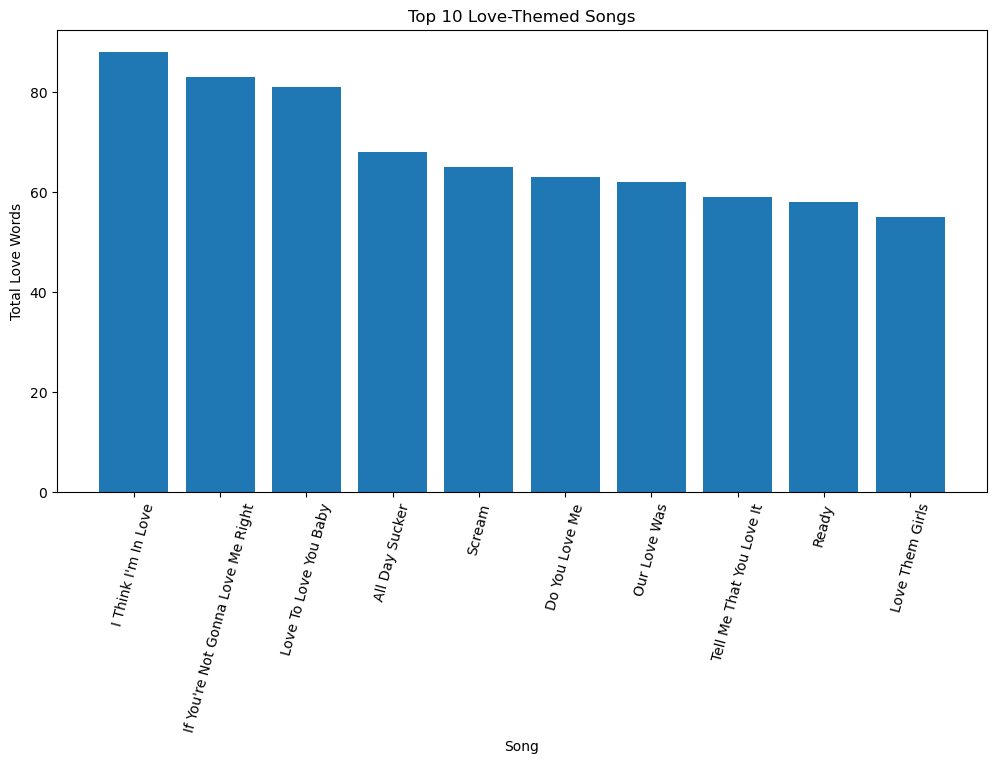

In [39]:
import matplotlib.pyplot as plt

top10 = df[["song", "total_love_words"]].sort_values(
    by="total_love_words",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10["song"], top10["total_love_words"])
plt.xticks(rotation=75)
plt.xlabel("Song")
plt.ylabel("Total Love Words")
plt.title("Top 10 Love-Themed Songs")
plt.show()

direct_love    92108
affection       1427
longing        17403
courtship       3088
commitment     31510
endearment     43560
poetic          4363
archaic         1669
dtype: int64


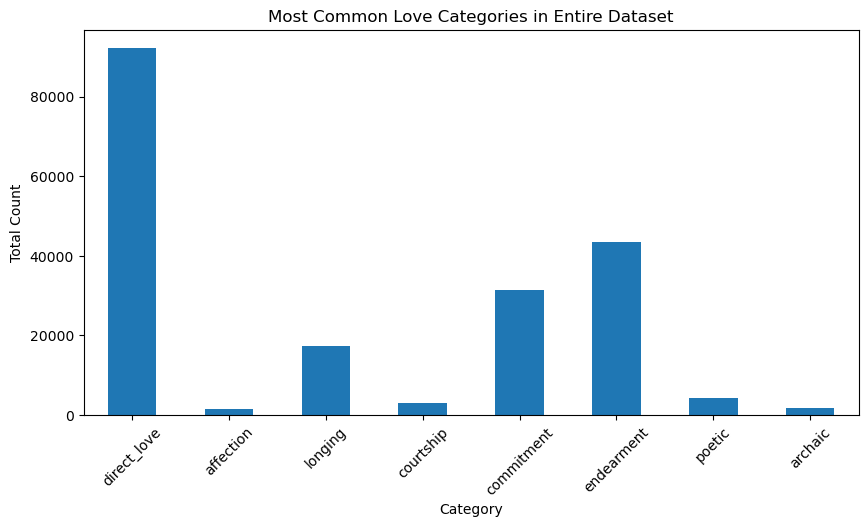

In [40]:
category_totals = results_df.sum()

print(category_totals)

category_totals.plot(
    kind="bar",
    figsize=(10,5),
    title="Most Common Love Categories in Entire Dataset"
)

plt.xlabel("Category")
plt.ylabel("Total Count")
plt.xticks(rotation=45)
plt.show()

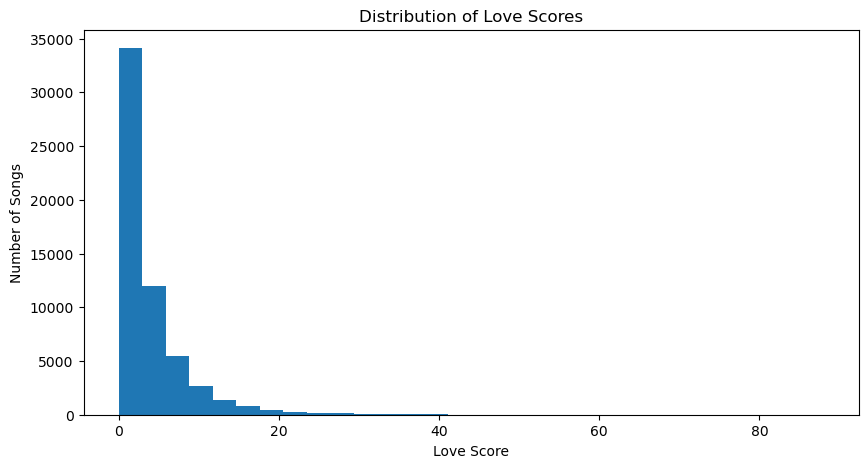

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["total_love_words"], bins=30)

plt.title("Distribution of Love Scores")
plt.xlabel("Love Score")
plt.ylabel("Number of Songs")

plt.show()

love_level
Low Love       52613
Medium Love     4813
High Love        224
Name: count, dtype: int64


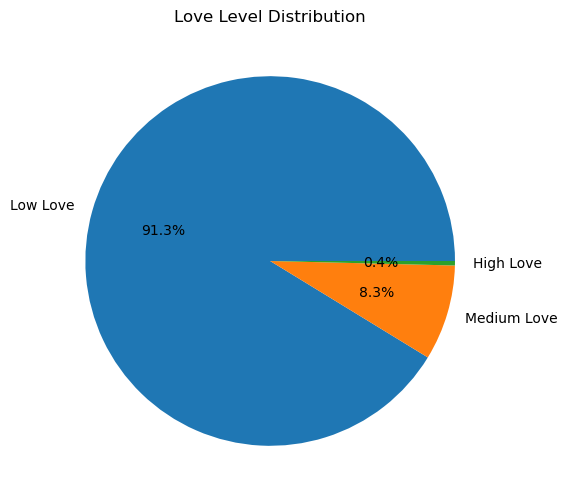

In [42]:
def classify(score):
    if score < 10:
        return "Low Love"
    elif score < 30:
        return "Medium Love"
    else:
        return "High Love"

df["love_level"] = df["total_love_words"].apply(classify)

print(df["love_level"].value_counts())

df["love_level"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    title="Love Level Distribution"
)

plt.ylabel("")
plt.show()

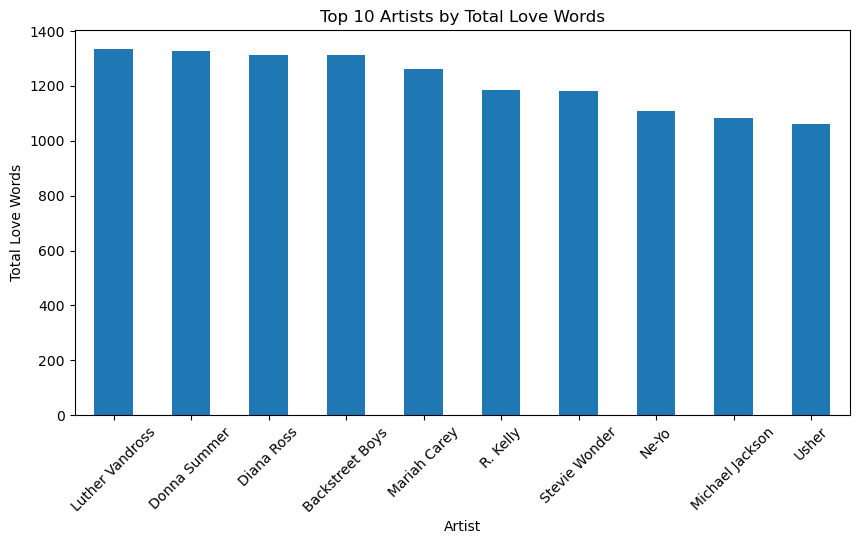

In [43]:
artist_scores = (
    df.groupby("artist")["total_love_words"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
artist_scores.plot(kind="bar")

plt.title("Top 10 Artists by Total Love Words")
plt.xlabel("Artist")
plt.ylabel("Total Love Words")
plt.xticks(rotation=45)

plt.show()

In [44]:
df.to_csv("love_lexicon_results.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
